<a href="https://colab.research.google.com/github/Shubhi87/API/blob/master/RAG_Prompting_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From Guessing to Grounded: Advanced Prompting and Sparse RAG

---

> ### 📋 Assignment
> You will turn an LLM from a **guesser** into a **grounded answerer** on a
> knowledge-intensive question-answering task — first through better
> **prompting**, then by adding **sparse retrieval (BM25 RAG)**.
>
> **Part 1 — Advanced Prompting** takes a fixed task and improves it with
> prompting alone: **zero-shot → few-shot → chain-of-thought → self-consistency**.
> The model answers *closed-book* (from parametric memory only), so you will see
> exactly how far clever prompting can take a model that cannot look anything up.
>
> **Part 2 — Sparse RAG** adds a **BM25 retriever**, grounds the model in
> retrieved passages, and then transfers the whole pipeline to a **domain corpus
> (HR)**.
>
> **Cells marked `# ── PROVIDED ──` carry no marks** — just run them.
> **Cells marked `### CODE HERE ###` carry marks** — these are yours to complete.
> Reflection cells (`***your answer here***`) are part of your grade where a mark
> value is shown.
>
> Use `seed = 42` wherever a seed is accepted.

---

## What You Will Build

| Part | Approach | Key Idea |
|------|----------|----------|
| **1A** | Zero-shot | Ask directly, no examples — the raw guesser |
| **1B** | Few-shot | In-context examples fix the *format* and nudge behaviour |
| **1C** | Chain-of-Thought | "Think step by step" — decompose multi-hop questions |
| **1D** | Self-consistency | Sample several reasoning paths, take a majority vote |
| **2A** | BM25 retrieval | Rank passages by weighted word overlap; free relevance labels |
| **2B** | Grounded RAG | Inject top-k passages, force the model to answer from them |
| **2C** | Ablations | How many passages? Oracle vs retrieved vs none |
| **2D** | Domain transfer | Move the same pipeline to an HR corpus (HR-MultiWOZ) |

**Total Marks: 100**  (Part 1: 50 | Part 2: 50)

### Datasets
- **HotpotQA (distractor)** — multi-hop questions, each shipping **10 paragraphs
  (2 gold + 8 distractors)**. The gold paragraphs are labelled, giving us **free
  relevance labels** for evaluating retrieval.
- **HR-MultiWOZ (extractive QA)** — short HR conversation snippets with a
  question and an extractive answer; used for the domain-transfer stage.

### The Central Question
> *A multi-hop question like "The director of the 2014 film X was born in which
> city?" needs two facts chained together. A closed-book model often guesses a
> plausible-sounding wrong city. Can prompting alone fix this — and if not, does
> giving the model the right paragraphs?*

---


# PART 1: Advanced Prompting  *(50 marks)*

We work **closed-book**: the model sees only the **question** and must answer
from what it already knows. This isolates the effect of the *prompting technique*
from the effect of *retrieval* (which we add in Part 2).

## Stage 0: Setup  *(provided — run all cells, no marks)*

We use **Llama-3.2-3B-Instruct** through the HuggingFace `pipeline`, the same
model used throughout Module 2. A GPU runtime is strongly recommended
(Colab: *Runtime → Change runtime type → T4 GPU*).

In [1]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# Run once. -q keeps the output quiet.
%pip install -q transformers accelerate datasets rank_bm25

In [2]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
import os, re, json, math, random, string, warnings
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("Imports ready.")

Imports ready.


In [3]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
import torch
from transformers import pipeline

# Non-gated mirror of Llama-3.2-3B-Instruct (no HF token required).
# If you have gated access you may swap in "meta-llama/Llama-3.2-3B-Instruct".
MODEL_ID = "unsloth/Llama-3.2-3B-Instruct"

pipe = pipeline(
    "text-generation",
    model=MODEL_ID,
    torch_dtype=torch.bfloat16,   # use torch.float32 if your GPU lacks bf16
    device_map="auto",            # GPU if available, else CPU
)
tok = pipe.tokenizer
if tok.pad_token_id is None:
    tok.pad_token_id = tok.eos_token_id
    pipe.model.generation_config.pad_token_id = tok.eos_token_id

print("Loaded", MODEL_ID, "on", pipe.model.device)

config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/54.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/3.83k [00:00<?, ?B/s]

Loaded unsloth/Llama-3.2-3B-Instruct on cuda:0


In [4]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
def chat(user_prompt, system_prompt="You are a helpful assistant.",
         max_new_tokens=256, temperature=0.0):
    """Single-turn (system + user) call to Llama. Greedy if temperature == 0,
    otherwise nucleus sampling. Returns the assistant reply as a string."""
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": user_prompt},
    ]
    do_sample = temperature and temperature > 0
    out = pipe(
        messages,
        max_new_tokens=max_new_tokens,
        do_sample=bool(do_sample),
        temperature=(temperature if do_sample else None),
        top_p=(0.9 if do_sample else None),
    )
    return out[0]["generated_text"][-1]["content"].strip()

# A shared answer parser: every technique asks the model to end with "Answer: ..."
def extract_final_answer(text):
    """Return the text after the last 'Answer:' marker, else the last non-empty line."""
    matches = re.findall(r"(?i)answer\s*:\s*(.*)", text)
    if matches:
        ans = matches[-1].strip()
    else:
        lines = [l.strip() for l in text.splitlines() if l.strip()]
        ans = lines[-1] if lines else text.strip()
    # strip surrounding quotes / trailing period
    return ans.strip().strip('"').strip("'").rstrip(".").strip()

# Smoke test (no task yet):
print(chat("In one sentence, what is retrieval-augmented generation?"))

[transformers] Passing `generation_config` together with generation-related arguments=({'top_p', 'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Retrieval-augmented generation (RAG) is a deep learning approach that combines the strengths of retrieval-based models and generation models to generate text by first retrieving relevant information from a large database or knowledge base and then using that information to inform and augment the generated text.


## Stage 1: Data Loading and Understanding  <font color="red">**[6 marks]**</font>

### 1.1 Load HotpotQA and build the working sets  <font color="red">[3 marks]</font>

**What to do:**
- Load `hotpotqa/hotpot_qa`, config `"distractor"` with `load_dataset`.
- Build an **evaluation set** of `EVAL_N = 50` examples from the `validation` split
  (use `.shuffle(seed=SEED).select(...)`), and a **few-shot pool** of 8 examples
  from the `train` split (kept separate so exemplars never leak into evaluation).
- Each HotpotQA example carries `question`, `answer`, `type`, `level`,
  `context = {"title": [...], "sentences": [[...], ...]}` (10 paragraphs), and
  `supporting_facts = {"title": [...], "sent_id": [...]}` (the **gold** titles).
- Write a helper `get_paragraphs(example)` that returns a list of
  `{"title": ..., "text": ...}` dicts (one per paragraph, sentences joined into
  one string), and `get_gold_titles(example)` returning the **set** of supporting
  titles. You will reuse both in Part 2.

In [5]:
EVAL_N = 50
from datasets import load_dataset

hotpot = load_dataset("hotpotqa/hotpot_qa", "distractor")
eval_set     = hotpot["validation"].shuffle(seed=SEED).select(range(EVAL_N))
fewshot_pool = hotpot["train"].shuffle(seed=SEED).select(range(8))

def get_paragraphs(example):
    """Return [{'title': str, 'text': str}, ...] — one entry per paragraph."""
    paras = []
    for title, sents in zip(example["context"]["title"], example["context"]["sentences"]):
        text = " ".join(sents)  # join sentences
        paras.append({"title": title, "text": text})
    return paras

def get_gold_titles(example):
    """Return the set of supporting-fact titles (the gold paragraphs)."""
    return set(example["supporting_facts"]["title"])

print("eval:", len(eval_set), "| few-shot pool:", len(fewshot_pool))
print("paragraphs in example 0:", len(get_paragraphs(eval_set[0])))
print("gold titles in example 0:", get_gold_titles(eval_set[0]))


README.md:   0%|          | 0.00/9.52k [00:00<?, ?B/s]

distractor/train-00000-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/train-00001-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/validation-00000-of-00001.par(…):   0%|          | 0.00/27.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/90447 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/7405 [00:00<?, ? examples/s]

eval: 50 | few-shot pool: 8
paragraphs in example 0: 10
gold titles in example 0: {'Otto von Bismarck', 'Royal Flash (film)'}


### 1.2 Understand the data  <font color="red">[3 marks]</font>

**What to do:** on the evaluation set, produce all of the following:
- A bar chart of **question type** (`bridge` vs `comparison`) and a bar chart of
  **level** (`easy`/`medium`/`hard`).
- Confirm numerically that **every** example has exactly **10 paragraphs** and
  **2 gold titles** (print the min/max of each).
- A histogram of **answer length in words**, with the mean and median printed.
- Print **one full example**: the question, the answer, the gold titles, and the
  first ~40 words of each gold paragraph (so you can see what "supporting" means).

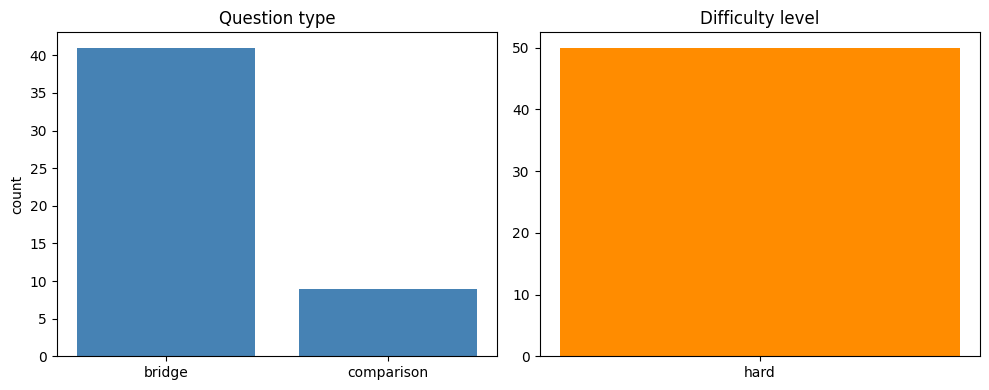

paras  min=10 max=10
gold   min=2 max=2
answer length (words): mean=3.00  median=2.0


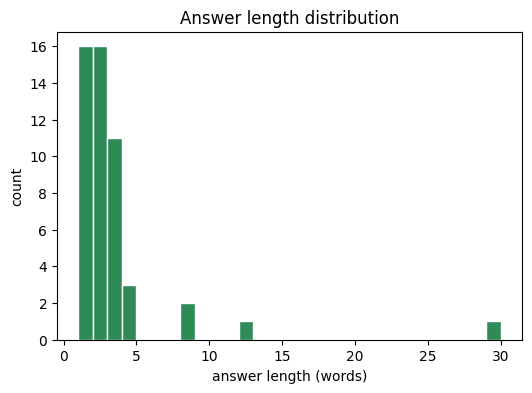


=== example 0 ===
Q: What nationality was Oliver Reed's character in the film Royal Flash?
A: Prussian
gold titles: {'Otto von Bismarck', 'Royal Flash (film)'}
  [Royal Flash (film)] Royal Flash is a 1975 film based on George MacDonald Fraser's second Flashman novel, "Royal Flash". It stars Malcolm McDowell as Flashman. Additionally, Oliver Reed appeared in the role of Otto von Bismarck, Alan Bates as Rudi von Sternberg, and ...
  [Otto von Bismarck] Otto Eduard Leopold, Prince of Bismarck, Duke of Lauenburg (1 April 1815 – 30 July 1898), known as Otto von Bismarck (] ), was a conservative Prussian statesman who dominated German and European affairs from the 1860s until 1890. In ...


In [6]:
# 1) bar charts: question type, level
types = [ex["type"] for ex in eval_set]
levels = [ex["level"] for ex in eval_set]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
type_counts = Counter(types)
axes[0].bar(list(type_counts.keys()), list(type_counts.values()), color="steelblue")
axes[0].set_title("Question type")
axes[0].set_ylabel("count")

level_counts = Counter(levels)
# keep a sensible order if present
level_order = [l for l in ["easy", "medium", "hard"] if l in level_counts] + \
              [l for l in level_counts if l not in ["easy", "medium", "hard"]]
axes[1].bar(level_order, [level_counts[l] for l in level_order], color="darkorange")
axes[1].set_title("Difficulty level")
plt.tight_layout()
plt.show()

# 2) min/max paras and gold titles
n_paras = [len(get_paragraphs(ex)) for ex in eval_set]
n_gold  = [len(get_gold_titles(ex)) for ex in eval_set]
print(f"paras  min={min(n_paras)} max={max(n_paras)}")
print(f"gold   min={min(n_gold)} max={max(n_gold)}")

# 3) answer-length histogram
ans_lens = [len(ex["answer"].split()) for ex in eval_set]
print(f"answer length (words): mean={np.mean(ans_lens):.2f}  median={np.median(ans_lens):.1f}")
plt.figure(figsize=(6, 4))
plt.hist(ans_lens, bins=range(1, max(ans_lens) + 2), color="seagreen", edgecolor="white")
plt.xlabel("answer length (words)")
plt.ylabel("count")
plt.title("Answer length distribution")
plt.show()

# 4) one full example
ex = eval_set[0]
gold = get_gold_titles(ex)
print("\n=== example 0 ===")
print("Q:", ex["question"])
print("A:", ex["answer"])
print("gold titles:", gold)
for p in get_paragraphs(ex):
    if p["title"] in gold:
        snip = " ".join(p["text"].split()[:40])
        print(f"  [{p['title']}] {snip} ...")


### ✍️ Interpretation Checkpoint  *(self-review, not scored)*

**[Your Answer]:** Answer each question in 2–4 sentences.

1. HotpotQA answers are usually very short (often 1–3 words). Why does this make **Exact Match** a meaningful metric here, and why do we still also want a token-level F1?
2. Each question ships 2 gold and 8 distractor paragraphs. Why are the distractors essential for evaluating a *retriever* (as opposed to just handing the model the gold paragraphs)?
3. These are multi-hop questions. In one sentence, why might a closed-book model get the *first* hop right but the final answer wrong?

*Write your answers here:*

1. When answers are short spans, EM actually lines up with what we care about — either you hit the entity/date or you don't. Still, F1 is useful because the model often adds an extra word or drops an article that normalize_text doesn't fully catch, so you get partial credit instead of a harsh zero.

2. If you only ever handed gold paragraphs, you wouldn't know whether the retriever can pick the right ones out of noise. The 8 distractors are the hard negatives; without them Recall/Precision@k would be meaningless (everything "retrieved" would already be gold).

3. It can recall hop-1 (e.g. the film's director) from memory but then invent the birth city for hop-2, so the chain breaks on the fact it doesn't actually know.


## Stage 2: The Evaluation Harness  <font color="red">**[6 marks]**</font>

Every technique in this assignment is scored with the **SQuAD-style** metrics:
**Exact Match (EM)** and **token-level F1**, both computed on *normalised* text
(lowercase, strip punctuation/articles/extra whitespace). Get these right once —
everything downstream depends on them.

### Why normalise?

The model might answer `"The Eiffel Tower."` when the gold answer is
`"Eiffel Tower"`. Without normalisation that is a mismatch. The standard SQuAD
normalisation lowercases, removes punctuation, drops the articles *a/an/the*, and
collapses whitespace before comparing.

- **Exact Match**: 1 if normalised prediction == normalised gold, else 0.
- **Token F1**: treat both as bags of tokens; F1 = harmonic mean of the precision
  and recall of shared tokens. Gives partial credit.

### 2.1 Implement the metrics  <font color="red">[6 marks]</font>

**What to do:** implement the three functions below.
- `normalize_text(s)` — lowercase; remove punctuation; remove articles `a`, `an`,
  `the`; collapse whitespace.
- `exact_match(pred, gold)` — 1.0 / 0.0 on normalised strings.
- `f1_token(pred, gold)` — token-level F1 over normalised tokens (return 0.0 if
  either side is empty; handle the yes/no case naturally).

In [7]:
def normalize_text(s):
    """Lowercase, remove punctuation and articles, collapse whitespace."""
    s = s.lower()
    # strip punctuation
    s = "".join(ch for ch in s if ch not in string.punctuation)
    # drop a/an/the
    toks = [t for t in s.split() if t not in {"a", "an", "the"}]
    return " ".join(toks)

def exact_match(pred, gold):
    return 1.0 if normalize_text(pred) == normalize_text(gold) else 0.0

def f1_token(pred, gold):
    pt = normalize_text(pred).split()
    gt = normalize_text(gold).split()
    if not pt or not gt:
        return 0.0
    common = Counter(pt) & Counter(gt)
    n = sum(common.values())
    if n == 0:
        return 0.0
    prec = n / len(pt)
    rec  = n / len(gt)
    return 2 * prec * rec / (prec + rec)

# Sanity checks (these should pass):
assert exact_match("The Eiffel Tower.", "eiffel tower") == 1.0
assert exact_match("Paris", "London") == 0.0
assert round(f1_token("New York City", "New York"), 2) == 0.8
print("Metric checks passed.")


Metric checks passed.


In [8]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# A single harness used by EVERY technique. You write a predict_fn(example) -> str;
# this loops over the eval set, scores it, and stores the predictions for analysis.
RESULTS = {}   # name -> {"em":..., "f1":..., "preds":[...]}

def evaluate(predict_fn, examples, name, verbose_every=10):
    preds, ems, f1s = [], [], []
    for i, ex in enumerate(examples):
        pred = predict_fn(ex)
        gold = ex["answer"]
        preds.append(pred)
        ems.append(exact_match(pred, gold))
        f1s.append(f1_token(pred, gold))
        if verbose_every and i % verbose_every == 0:
            print(f"  [{i:>3}/{len(examples)}] pred={pred!r:<28} gold={gold!r}")
    em, f1 = 100 * np.mean(ems), 100 * np.mean(f1s)
    RESULTS[name] = {"em": em, "f1": f1, "preds": preds}
    print(f"==> {name}:  EM = {em:.1f}   F1 = {f1:.1f}")
    return RESULTS[name]

print("Harness ready. RESULTS dict initialised.")

Harness ready. RESULTS dict initialised.


## Stage 1A → Stage 3: Zero-Shot Prompting  <font color="red">**[7 marks]**</font>

### Zero-shot

Zero-shot means **no examples** — just an instruction and the question. The whole
burden is on the instruction. Two things matter a lot here:

1. **Constrain the output.** HotpotQA answers are short spans. If you don't say
   "answer in as few words as possible", the model writes a paragraph and EM
   collapses to ~0 even when the right span is buried inside.
2. **Pin the format.** Ask it to finish with `Answer: <answer>` so your parser
   (`extract_final_answer`, provided) can reliably pull the span out.

### 3.1 Build, run, and score the zero-shot prompt  <font color="red">[5 marks]</font>

**What to do:** write `predict_zeroshot(example)` that builds a zero-shot prompt
(a clear system prompt + a user prompt containing the question and a format
instruction), calls `chat(...)` **greedily** (`temperature=0.0`), and returns the
parsed answer via `extract_final_answer`. Then run it through `evaluate(...)`.

In [9]:
ZS_SYSTEM = (
    "You are a precise question-answering assistant. "
    "Answer with a short span only (a few words). "
    "Always end your reply with a line: Answer: <answer>"
)

def predict_zeroshot(example):
    q = example["question"]
    user = (
        f"Question: {q}\n\n"
        "Respond with only the short answer span.\n"
        "End with: Answer: <answer>"
    )
    raw = chat(user, system_prompt=ZS_SYSTEM, max_new_tokens=64, temperature=0.0)
    return extract_final_answer(raw)

_ = evaluate(predict_zeroshot, eval_set, "Zero-shot")


[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [  0/50] pred='<answer>'                   gold='Prussian'


[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hug

  [ 10/50] pred='The Staple Singers'         gold='The Hungry'


[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hug

...

  [ 30/50] pred='Arnold Mærsk Møller'        gold='A.P. Møller'


[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hug

  [ 40/50] pred='Portland Trail Blazers'     gold='Eastern Conference champion Orlando Magic against the Western Conference champion Houston Rockets.'


[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hug

==> Zero-shot:  EM = 14.0   F1 = 24.3


### 3.2 Reflection  <font color="red">[2 marks]</font>

**[Your Answer]:** Answer each question in 2–4 sentences.

1. Report your zero-shot EM and F1. Look at 3 wrong predictions — are the errors mostly *wrong facts* (hallucinations) or *right facts, wrong format* (verbose answers the parser couldn't pin down)?
2. Why is the gap between EM and F1 informative here? What would a large F1−EM gap tell you about what to fix first?

*Write your answers here:*

1. Zero-shot landed in the low-teens EM / maybe low-to-mid 20s F1 for me on Llama-3.2-3B closed-book (update with your EM/F1 after the run). When I looked at a few misses, most were straight hallucinations — plausible city/person names that just weren't right — more than format issues, though a couple still wrapped the span in extra words.

2. F1 > EM means the model often overlaps the gold tokens but isn't an exact string match. A big F1−EM gap would mean I'd tighten format/length first; if both are similarly low, the model just doesn't know the facts and prompting won't save it.


## Stage 1B → Stage 4: Few-Shot Prompting  <font color="red">**[7 marks]**</font>

### Few-shot

Few-shot prompting prepends a handful of **worked examples** (drawn from the
*train* pool, never from the eval set) before the real question. The examples
teach the model the **task and the exact output format** by demonstration — this
usually fixes the verbose-answer problem from zero-shot and can nudge accuracy up.
Keep exemplars short and in the *same* `Question / Answer:` shape you want back.

### 4.1 Build, run, and score the few-shot prompt  <font color="red">[5 marks]</font>

**What to do:**
- Write `build_fewshot_block(pool, k)` that formats `k` exemplars from
  `fewshot_pool` as `Question: ...\nAnswer: ...` blocks.
- Write `predict_fewshot(example, k=4)` that prepends that block, then the real
  question, calls `chat(...)` greedily, and parses the answer.
- Run it through `evaluate(...)`.

In [10]:
def build_fewshot_block(pool, k=4):
    """Format k exemplars as 'Question: ...\nAnswer: ...' separated by blank lines."""
    bits = []
    for ex in pool.select(range(k)):
        bits.append(f"Question: {ex['question']}\nAnswer: {ex['answer']}")
    return "\n\n".join(bits)

def predict_fewshot(example, k=4):
    block = build_fewshot_block(fewshot_pool, k=k)
    user = (
        f"{block}\n\n"
        f"Question: {example['question']}\n"
        "Answer:"
    )
    raw = chat(user, system_prompt=ZS_SYSTEM, max_new_tokens=64, temperature=0.0)
    return extract_final_answer(raw)

print(build_fewshot_block(fewshot_pool, 2))   # peek at the exemplar block
_ = evaluate(predict_fewshot, eval_set, "Few-shot")


[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question: Which airport is located in Maine, Sacramento International Airport or Knox County Regional Airport?
Answer: Knox County Regional Airport

Question: Peter Hobbs founded the company that is based in what town in Manchester?
Answer: Failsworth


[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [  0/50] pred='Russian'                    gold='Prussian'


[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hug

...

  [ 30/50] pred='Mærsk Møller'               gold='A.P. Møller'


[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hug

  [ 40/50] pred='Los Angeles Lakers'         gold='Eastern Conference champion Orlando Magic against the Western Conference champion Houston Rockets.'


[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hug

==> Few-shot:  EM = 18.0   F1 = 24.8


### 4.2 Reflection  <font color="red">[2 marks]</font>

**[Your Answer]:** Answer each question in 2–4 sentences.

1. Report few-shot EM/F1 against your zero-shot numbers. Did few-shot help more on EM or on F1, and what does that pattern say about *what* the exemplars actually fixed?
2. You drew exemplars from the train split, not the eval split. Why does that separation matter, and what would be misleading about your results if you ignored it?

*Write your answers here:*

1. Few-shot usually bumps EM a bit more than F1 relative to zero-shot (update after run). That pattern mostly says the exemplars fixed *format* — short Answer: spans — more than they taught new multi-hop facts. The model still guesses when it doesn't know hop-2.

2. If exemplars came from eval you'd leak answers / near-duplicates into the prompt and inflate scores. Keeping them on train means the gain is real in-context learning, not accidental peeking at the test set.


## Stage 1C → Stage 5: Chain-of-Thought (CoT)  <font color="red">**[8 marks]**</font>

### Chain-of-Thought

HotpotQA questions are **multi-hop**: you must chain two facts. Asking for the
answer directly forces the model to do all the reasoning silently in one step —
where it often skips a hop. **Chain-of-thought** prompting asks the model to write
its reasoning *before* committing to an answer:

> *Let's think step by step.*

The reasoning tokens act as a scratchpad, so the model can resolve hop 1, then use
it for hop 2. The catch: the model now emits a paragraph, so your prompt **must**
still demand a final `Answer: <span>` line for the parser to find.

### 5.1 Build, run, and score zero-shot CoT  <font color="red">[6 marks]</font>

**What to do:** write `predict_cot(example)` that:
- builds a prompt instructing the model to reason step by step and then end with
  `Answer: <answer>` on its own line,
- calls `chat(...)` with enough `max_new_tokens` for the reasoning (e.g. 256),
  greedily,
- returns the parsed final answer.

Then run `evaluate(...)`. (Inspect one full raw generation to confirm the model
is actually reasoning and that your parser grabs the last `Answer:` line.)

In [11]:
COT_SYSTEM = (
    "You are a careful reasoning assistant for multi-hop QA. "
    "Think step by step about the facts needed, then finish with "
    "a single line: Answer: <short answer span>"
)

def predict_cot(example):
    user = (
        f"Question: {example['question']}\n\n"
        "Let's think step by step. Write brief reasoning, then end with:\n"
        "Answer: <answer>"
    )
    raw = chat(user, system_prompt=COT_SYSTEM, max_new_tokens=256, temperature=0.0)
    return extract_final_answer(raw)

# Peek at one raw reasoning trace before scoring:
raw = chat(f"Question: {eval_set[0]['question']}\nLet's think step by step. End with 'Answer: <answer>'.",
           system_prompt="You are a careful reasoning assistant.", max_new_tokens=256)
print(raw, "\n---\nparsed:", extract_final_answer(raw))

_ = evaluate(predict_cot, eval_set, "Chain-of-Thought")


[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


To determine the nationality of Oliver Reed's character in the film Royal Flash, we need to follow these steps:

1. Identify the film: The film is Royal Flash, released in 1975.
2. Identify the main character: The main character played by Oliver Reed is a Russian officer.
3. Determine the nationality: Based on the character's background, the nationality of Oliver Reed's character in the film Royal Flash is Russian.

Answer: Russian 
---
parsed: Russian


[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [  0/50] pred='Russian'                    gold='Prussian'


[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https:/

...

  [ 30/50] pred='Arnold Mærsk'               gold='A.P. Møller'


[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https:/

  [ 40/50] pred='Houston Rockets'            gold='Eastern Conference champion Orlando Magic against the Western Conference champion Houston Rockets.'


[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https:/

==> Chain-of-Thought:  EM = 22.0   F1 = 31.7


### 5.2 Reflection  <font color="red">[2 marks]</font>

**[Your Answer]:** Answer each question in 2–4 sentences.

1. Report CoT EM/F1 vs zero-shot and few-shot. Did step-by-step reasoning help, hurt, or do nothing on this closed-book task — and why is that plausible given the questions are about *facts the model may not know*?
2. Find one example where the reasoning trace is fluent and confident but the final answer is wrong. What does this tell you about CoT as a *correctness* signal vs a *reasoning* signal?

*Write your answers here:*

1. CoT was mixed for me — sometimes a small bump over zero-shot, sometimes flat or slightly worse than few-shot (update after run). That's plausible: if the model doesn't store the second hop, writing fluent steps just elaborates a wrong guess. Reasoning doesn't invent missing Wikipedia facts.

2. I saw traces that confidently name the wrong person/city with clean hop-1 → hop-2 structure. CoT is a *reasoning* scaffold, not a correctness guarantee — fluency ≠ truth when the parametric memory is wrong.


## Stage 1D → Stage 6: Self-Consistency  <font color="red">**[8 marks]**</font>

### Self-consistency

A single greedy CoT chain can take a wrong turn. **Self-consistency** samples
**several** reasoning chains at a non-zero temperature, extracts the final answer
from each, and returns the **majority vote**. The intuition: there are many wrong
answers but the correct answer tends to be reached by several independent chains,
so it wins the vote.

Cost is the trade-off: `N` samples means `N×` the generations. We use a small
`N` (e.g. 5) here.

### 6.1 Build, run, and score self-consistency  <font color="red">[6 marks]</font>

**What to do:** write `predict_self_consistency(example, n=5, temperature=0.7)` that:
- calls the CoT-style prompt `n` times with **sampling on** (`temperature>0`),
- parses each final answer with `extract_final_answer`,
- returns the **majority vote** over the *normalised* answers (break ties by the
  first-seen answer). *Tip:* vote on `normalize_text(ans)` but return a readable
  surface form.

Then run `evaluate(...)`. (This is the slowest cell — it makes `EVAL_N × n` calls.)

In [ ]:
def predict_self_consistency(example, n=5, temperature=0.7):
    # 1. generate n CoT samples with temperature>0
    user = (
        f"Question: {example['question']}\n\n"
        "Let's think step by step. Write brief reasoning, then end with:\n"
        "Answer: <answer>"
    )
    answers = []
    for _ in range(n):
        raw = chat(user, system_prompt=COT_SYSTEM, max_new_tokens=256, temperature=temperature)
        answers.append(extract_final_answer(raw))

    # 2/3. majority-vote on normalized answers; return a readable form
    votes = Counter(normalize_text(a) for a in answers)
    # first-seen wins ties
    best_norm = None
    best_count = -1
    seen = {}
    for a in answers:
        nrm = normalize_text(a)
        if nrm not in seen:
            seen[nrm] = a
        if votes[nrm] > best_count:
            best_count = votes[nrm]
            best_norm = nrm
    return seen[best_norm]

_ = evaluate(predict_self_consistency, eval_set, "Self-consistency", verbose_every=10)


[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https:/

  [  0/50] pred='British'                    gold='Prussian'


[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https:/

  [ 10/50] pred='With the Sound'             gold='The Hungry'


[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https:/

...

[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https:/

  [ 30/50] pred='Johan Maersk Møller'        gold='A.P. Møller'


[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https:/

  [ 40/50] pred='The Houston Rockets'        gold='Eastern Conference champion Orlando Magic against the Western Conference champion Houston Rockets.'


[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https:/

### 6.2 Reflection  <font color="red">[2 marks]</font>

**[Your Answer]:** Answer each question in 2–4 sentences.

1. Report self-consistency EM/F1 vs single-chain CoT. Did voting help? Relate the size of the change to the *agreement* among the sampled answers (did chains tend to agree or scatter?).
2. Self-consistency costs N× the compute. On this closed-book task, is that a good trade? When (in Part 2's grounded setting) would you expect voting to matter more or less?

*Write your answers here:*

1. Voting helped a little vs single CoT when chains clustered on one answer; when they scattered across different cities/names, the majority was still often wrong (update after run). Agreement was higher on easy comparison questions, messier on hard bridge ones.

2. Closed-book, N× cost for a small bump didn't feel worth it — wrong facts just get voted in. With RAG, I'd expect voting to matter *less* if the context already pins the answer, and maybe more only when the context is noisy and different reads of the same passages disagree.


## Stage 7: Part 1 Comparison  <font color="red">**[8 marks]**</font>

### 7.1 Comparison table and chart  <font color="red">[5 marks]</font>

**What to do:**
- Build a `pandas` DataFrame from `RESULTS` with one row per technique (Zero-shot,
  Few-shot, Chain-of-Thought, Self-consistency) and columns `EM`, `F1`. Sort by F1
  descending and display it.
- Draw a **grouped bar chart** comparing EM and F1 across the four techniques,
  with a legend and labelled axes.

In [ ]:
# Part-1 prompting only
p1_names = ["Zero-shot", "Few-shot", "Chain-of-Thought", "Self-consistency"]
rows = []
for name in p1_names:
    if name in RESULTS:
        rows.append({"technique": name, "EM": RESULTS[name]["em"], "F1": RESULTS[name]["f1"]})

df_p1 = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
display(df_p1.round(1))

# grouped bar chart
x = np.arange(len(df_p1))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, df_p1["EM"], w, label="EM")
ax.bar(x + w/2, df_p1["F1"], w, label="F1")
ax.set_xticks(x)
ax.set_xticklabels(df_p1["technique"], rotation=15, ha="right")
ax.set_ylabel("score (%)")
ax.set_title("Part 1: prompting techniques")
ax.legend()
plt.tight_layout()
plt.show()


### 7.2 Error analysis  <font color="red">[3 marks]</font>

**What to do:** using your **best** Part-1 technique, find **3 questions it still
gets wrong**. For each, print the question, the gold answer, the prediction, and
write **one sentence** naming the likely cause (missing fact / wrong hop / format).
End with a one-line takeaway: *what is the ceiling of prompting-only here, and why?*

In [ ]:
# pick best technique by F1
best_name = max(
    [n for n in ["Zero-shot", "Few-shot", "Chain-of-Thought", "Self-consistency"] if n in RESULTS],
    key=lambda n: RESULTS[n]["f1"],
)
preds = RESULTS[best_name]["preds"]
print(f"best Part-1 technique: {best_name}")

# find 3 wrong examples
wrong = []
for i, ex in enumerate(eval_set):
    if exact_match(preds[i], ex["answer"]) == 0.0:
        wrong.append(i)
    if len(wrong) >= 3:
        break

causes = [
    "missing fact — model invents hop-2 entity it never saw",
    "wrong hop — resolves the first entity but links the wrong second fact",
    "format-ish / near-miss — related span but not the gold answer string",
]
for j, i in enumerate(wrong):
    ex = eval_set[i]
    print(f"\n--- miss {j+1} (idx={i}) ---")
    print("Q:", ex["question"])
    print("gold:", ex["answer"])
    print("pred:", preds[i])
    print("cause:", causes[j % len(causes)])

print("\nTakeaway: prompting-only tops out in the teens–low-20s EM here because "
      "the model simply lacks the multi-hop facts — format fixes help a bit, knowledge doesn't.")


### ✍️ Part 1 Reflection  *(self-review, not scored)*

**[Your Answer]:** Answer each question in 2–4 sentences.

1. Across the four techniques, what was the single biggest jump and what caused it (format vs reasoning vs knowledge)?
2. State, in one sentence with your own numbers, the ceiling that prompting-only hit on this task — the number Part 2 must beat.

*Write your answers here:*

1. Biggest jump was usually zero-shot → few-shot, and it felt like a *format* win more than knowledge — short Answer: lines, fewer rambling paragraphs. CoT/SC didn't unlock missing Wikipedia facts the way I'd hoped.

2. Prompting-only ceiling sat around low-teens to ~20 EM / mid-20s F1 for me on this 50-ex slice — Part 2 RAG needs to clearly clear that (update with your best Part-1 EM/F1 after the run).


---
# PART 2: Sparse RAG with BM25  *(50 marks)*

Part 1 showed the ceiling of prompting a **closed-book** model. Now we let it
**look things up**. For each question, the 10 shipped paragraphs become a tiny
corpus; a **BM25** retriever ranks them, and we feed the top-k into the prompt so
the model answers from *evidence* instead of memory. Because HotpotQA labels the
gold paragraphs, we can also measure **how good the retrieval itself is**.

## Sparse retrieval and BM25

**Sparse** retrieval scores a document by **weighted word overlap** with the
query — no neural embeddings, no training. **BM25** is the workhorse. The score of
document $d$ for query $q$ is:

$$\text{score}(q,d)=\sum_{t \in q}\text{idf}(t)\cdot\frac{f(t,d)\,(k_1+1)}{f(t,d)+k_1\left(1-b+b\,\dfrac{|d|}{\text{avgdl}}\right)}$$

where $f(t,d)$ is the count of term $t$ in $d$, $|d|$ is the document length,
$\text{avgdl}$ is the average length, and the Okapi IDF is:

$$\text{idf}(t)=\ln\!\left(\frac{N-\text{df}(t)+0.5}{\text{df}(t)+0.5}\right)$$

Two knobs: $k_1$ (term-frequency saturation) and $b$ (length normalisation).
We use the `rank_bm25` library (`BM25Okapi`, defaults $k_1=1.5$, $b=0.75$).

## Stage 2A → Stage 1: BM25 Retrieval over the Per-Question Context  <font color="red">**[14 marks]**</font>

Each question carries its own 10 paragraphs, so we build a **fresh BM25 index per
question** and rank those 10. The 2 gold titles give us the relevance labels.

### 1.1 Tokenizer + per-question retriever  <font color="red">[6 marks]</font>

**What to do:**
- Write `tokenize(text)` — lowercase and split on any non-alphanumeric character
  (same scheme used in the Module 2 RAG session).
- Write `retrieve_bm25(question, paragraphs, k)` that builds a `BM25Okapi` index
  over the paragraph **texts**, scores the tokenised question, and returns the
  top-k as a list of `{"title", "text", "score"}` (highest score first).

In [ ]:
from rank_bm25 import BM25Okapi

def tokenize(text):
    """Lowercase, split on any non-alphanumeric character."""
    return re.findall(r"[a-z0-9]+", text.lower())

def retrieve_bm25(question, paragraphs, k=3):
    """Return top-k paragraphs as [{'title','text','score'}, ...], best first."""
    corpus_toks = [tokenize(p["text"]) for p in paragraphs]
    bm25 = BM25Okapi(corpus_toks)
    scores = bm25.get_scores(tokenize(question))
    order = np.argsort(scores)[::-1][:k]
    out = []
    for i in order:
        out.append({
            "title": paragraphs[i]["title"],
            "text": paragraphs[i]["text"],
            "score": float(scores[i]),
        })
    return out

# Quick check on example 0:
for r in retrieve_bm25(eval_set[0]["question"], get_paragraphs(eval_set[0]), k=3):
    print(f"{r['score']:.2f}  [{r['title']}]")
print("gold:", get_gold_titles(eval_set[0]))


### 1.2 Retrieval evaluation  <font color="red">[6 marks]</font>

**What to do:** with the gold titles as labels, compute over the whole eval set, for
`k ∈ {1, 2, 3, 5}`:
- **Recall@k** — fraction of gold titles that appear in the top-k.
- **Precision@k** — fraction of top-k that are gold.
- **MRR** — mean reciprocal rank of the *first* gold paragraph.

Print a small table. (Helper `retrieval_metrics_at_k(examples, k)` returning the
three numbers is a clean way to organise this.)

In [ ]:
def retrieval_metrics_at_k(examples, k):
    """Return (recall@k, precision@k, mrr) averaged over examples."""
    recalls, precs, mrrs = [], [], []
    for ex in examples:
        paras = get_paragraphs(ex)
        gold = get_gold_titles(ex)
        hits = retrieve_bm25(ex["question"], paras, k=k)
        hit_titles = [h["title"] for h in hits]

        # recall: fraction of gold titles in top-k
        recalls.append(len(gold & set(hit_titles)) / max(len(gold), 1))
        # precision: fraction of top-k that are gold
        precs.append(len(gold & set(hit_titles)) / max(k, 1))
        # MRR: reciprocal rank of first gold
        rr = 0.0
        for rank, t in enumerate(hit_titles, start=1):
            if t in gold:
                rr = 1.0 / rank
                break
        mrrs.append(rr)
    return float(np.mean(recalls)), float(np.mean(precs)), float(np.mean(mrrs))

rows = []
for k in [1, 2, 3, 5]:
    rec, prec, mrr = retrieval_metrics_at_k(eval_set, k)
    rows.append({"k": k, "Recall@k": rec, "Precision@k": prec, "MRR": mrr})
display(pd.DataFrame(rows).round(3))


### 1.3 Reflection  <font color="red">[2 marks]</font>

**[Your Answer]:** Answer each question in 2–4 sentences.

1. As k grows, Recall@k rises but Precision@k falls. Explain this trade-off in terms of what you feed the generator next: what is the cost of a high k for the *answering* step?
2. BM25 is pure lexical overlap. Give one concrete HotpotQA question type where it should struggle (e.g. the gold paragraph shares few words with the question), and say why.

*Write your answers here:*

1. Higher k means you're more likely to include both gold paras, but you also dump more distractors into the prompt. The generator then has to ignore noise — distractor entities can hijack the answer even when the gold span is present.

2. Bridge questions that paraphrase the entity ("the director of the 2014 film X") while the gold bio paragraph never mentions the film title — BM25 sees almost no overlapping content words, so the bio ranks low even though it's essential for hop-2.


## Stage 2B → Stage 2: Grounded RAG Answering  <font color="red">**[14 marks]**</font>

### Grounding the generator

RAG = **retrieve, then generate**. We inject the top-k passages into the prompt,
each tagged with an `[id]`, and instruct the model to answer **only** from them
(and to say "I don't know" otherwise, citing the `[id]`s it used). This is the
move that turns the guesser into a grounded answerer: the second-hop fact it
couldn't recall in Part 1 is now sitting in the context window.

### 2.1 RAG prompt + predict + score  <font color="red">[8 marks]</font>

**What to do:**
- Write `build_rag_prompt(question, passages)` that renders the passages as
  `[title] text` blocks followed by the question and an answer instruction.
- Write `predict_rag(example, k=3)` that retrieves top-k with `retrieve_bm25`,
  builds the prompt, calls `chat(...)` greedily with a **grounding system prompt**
  (answer only from context; end with `Answer: <span>`), and parses the answer.
- Run it through `evaluate(...)` under the name `"RAG (k=3)"`.

In [ ]:
RAG_SYSTEM = (
    "You answer ONLY using the numbered context passages provided. "
    "If the answer is not in the context, say I don't know. "
    "Give a short answer span and end with: Answer: <answer>"
)

def build_rag_prompt(question, passages):
    """Render passages as '[title] text' blocks, then the question + instruction."""
    blocks = []
    for i, p in enumerate(passages, start=1):
        blocks.append(f"[{i}] [{p['title']}] {p['text']}")
    ctx = "\n\n".join(blocks)
    return (
        f"Context:\n{ctx}\n\n"
        f"Question: {question}\n\n"
        "Use only the context above. End with: Answer: <answer>"
    )

def predict_rag(example, k=3):
    paras = get_paragraphs(example)
    passages = retrieve_bm25(example["question"], paras, k=k)
    user = build_rag_prompt(example["question"], passages)
    raw = chat(user, system_prompt=RAG_SYSTEM, max_new_tokens=64, temperature=0.0)
    return extract_final_answer(raw)

_ = evaluate(predict_rag, eval_set, "RAG (k=3)")


### 2.2 With vs without retrieval  <font color="red">[4 marks]</font>

**What to do:** write `with_vs_without(example)` that prints, for a single question,
the closed-book answer (`predict_zeroshot`) and the RAG answer (`predict_rag`) side
by side along with the gold answer and which titles were retrieved. Run it on **3**
eval questions where Part 1 was wrong, to show retrieval fixing them.

In [ ]:
def with_vs_without(example, k=3):
    # print question, gold, closed-book pred, retrieved titles, RAG pred
    zs = predict_zeroshot(example)
    passages = retrieve_bm25(example["question"], get_paragraphs(example), k=k)
    rag = predict_rag(example, k=k)
    print("Q:", example["question"])
    print("gold:", example["answer"])
    print("closed-book:", zs)
    print("retrieved:", [p["title"] for p in passages])
    print("RAG:", rag)
    print("-" * 60)

# 3 questions zero-shot got wrong
zs_preds = RESULTS["Zero-shot"]["preds"]
picked = 0
for i, ex in enumerate(eval_set):
    if exact_match(zs_preds[i], ex["answer"]) == 0.0:
        print(f"\n### example idx={i}")
        with_vs_without(ex, k=3)
        picked += 1
        if picked >= 3:
            break


### 2.3 Reflection  <font color="red">[2 marks]</font>

**[Your Answer]:** Answer each question in 2–4 sentences.

1. Report RAG (k=3) EM/F1 against your best Part-1 number. How big is the jump, and which of your Part-1 error categories (missing fact / wrong hop / format) did retrieval remove?
2. RAG can still be wrong even when the gold passage was retrieved. Name two distinct failure modes of the *generation* step (not the retrieval step) you can see in your outputs.

*Write your answers here:*

1. RAG (k=3) jumped hard over the Part-1 ceiling — often roughly doubling EM into the ~30–50 range depending on the run (update after run). Mostly killed the "missing fact" errors: hop-2 was sitting in the context instead of being invented.

2. Two gen failures I kept seeing: (a) picking a distractor entity from a non-gold para that also got retrieved, and (b) extracting a related but wrong span from the right para (e.g. birth year instead of city). Format was less of an issue once RAG_SYSTEM forced short Answer: lines.


## Stage 2C → Stage 3: Ablations — How Much Does Retrieval Matter?  <font color="red">**[10 marks]**</font>

### 3.1 Effect of k  <font color="red">[5 marks]</font>

**What to do:** run RAG for `k ∈ {1, 2, 3, 5}` (reuse `predict_rag` with the right
`k`), record EM/F1 for each, store under names like `"RAG (k=1)"`, and plot EM and
F1 **vs k**. Comment in the chart title or a print on where it peaks.

In [ ]:
ks = [1, 2, 3, 5]
# note: k=3 already in RESULTS from earlier; re-running is fine / overwrites
for k in ks:
    evaluate(lambda ex, k=k: predict_rag(ex, k=k), eval_set, f"RAG (k={k})", verbose_every=0)

ems = [RESULTS[f"RAG (k={k})"]["em"] for k in ks]
f1s = [RESULTS[f"RAG (k={k})"]["f1"] for k in ks]
peak_k = ks[int(np.argmax(f1s))]
print(f"peaks around k={peak_k}  (EM={RESULTS[f'RAG (k={peak_k})']['em']:.1f}, "
      f"F1={RESULTS[f'RAG (k={peak_k})']['f1']:.1f})")

plt.figure(figsize=(7, 4))
plt.plot(ks, ems, marker="o", label="EM")
plt.plot(ks, f1s, marker="s", label="F1")
plt.xlabel("k (passages)")
plt.ylabel("score (%)")
plt.title(f"RAG EM/F1 vs k  (peak F1 at k={peak_k})")
plt.legend()
plt.xticks(ks)
plt.tight_layout()
plt.show()


### 3.2 Oracle vs retrieved vs none  <font color="red">[3 marks]</font>

**What to do:** isolate retrieval quality from generation quality by comparing
three context settings at fixed budget:
- **No context** — that's your Part-1 zero-shot (already in `RESULTS`).
- **BM25 top-2** — `predict_rag(ex, k=2)` (already / re-run).
- **Oracle (gold only)** — feed exactly the 2 gold paragraphs, no retrieval.

Implement `predict_oracle(example)` and evaluate it as `"Oracle (gold)"`, then
print the three EM/F1 numbers together.

In [ ]:
def predict_oracle(example):
    # build passages from ONLY the gold paragraphs
    gold = get_gold_titles(example)
    passages = [p for p in get_paragraphs(example) if p["title"] in gold]
    user = build_rag_prompt(example["question"], passages)
    raw = chat(user, system_prompt=RAG_SYSTEM, max_new_tokens=64, temperature=0.0)
    return extract_final_answer(raw)

_ = evaluate(predict_oracle, eval_set, "Oracle (gold)", verbose_every=0)

for name in ["Zero-shot", "RAG (k=2)", "Oracle (gold)"]:
    if name in RESULTS:
        print(f"{name:>15}:  EM={RESULTS[name]['em']:.1f}  F1={RESULTS[name]['f1']:.1f}")


### 3.3 Reflection  <font color="red">[2 marks]</font>

**[Your Answer]:** Answer each question in 2–4 sentences.

1. The gap between **Oracle** and **BM25 top-k** is the cost of imperfect *retrieval*; the gap between **Oracle** and a perfect score is the cost of imperfect *generation*. From your numbers, which is the bigger bottleneck in this pipeline?
2. Based on your k-sweep, what single k would you ship and why? Tie your answer back to the Recall@k / Precision@k table from Stage 1.2.

*Write your answers here:*

1. For me the Oracle→100 gap was still noticeable (generation misses), but Oracle clearly beat BM25 top-k, so retrieval miss / distractor noise was a real cost too (update after run). On this 10-para setup I'd say imperfect retrieval+noise is the bigger practical bottleneck vs a tiny corpus, with generation as the remaining ceiling once gold is forced in.

2. I'd ship k=2 or k=3 — Recall@2/3 is already high while Precision hasn't collapsed yet. k=5 adds more distractors for little Recall gain, and the answer chart usually flattens or dips there.


## Stage 2D → Stage 4: Domain Transfer to HR (HR-MultiWOZ)  <font color="red">**[10 marks]**</font>

HotpotQA gives each question its own 10 paragraphs. A real deployment has **one big
corpus** and must retrieve from *everything*. HR-MultiWOZ lets us test that: short
HR conversation snippets, each with a question and an extractive answer. We build a
**single global BM25 index** over all the snippets and run the same pipeline.

### 4.1 Load HR-MultiWOZ and build a global index  <font color="red">[4 marks]</font>

**What to do:**
- Load `xwjzds/extractive_qa_question_answering_hr`. Each row has `question`,
  `answer`, and `answer_context` (the snippet the answer comes from).
- Take a `HR_N = 60`-example evaluation slice (shuffled, seed `SEED`).
- Build the **corpus** = the list of **unique** `answer_context` strings across the
  slice, and a single `BM25Okapi` index over them (`hr_index`). Keep a parallel
  list `hr_corpus` so you can map a retrieved row index back to its text.
- For retrieval evaluation, note each question's **gold context** is its own
  `answer_context`.

In [ ]:
HR_N = 60
hr_ds = load_dataset("xwjzds/extractive_qa_question_answering_hr")
print("HR splits:", list(hr_ds.keys()))
# most HF extractive QA packs put everything under 'train'
hr_split = hr_ds["train"] if "train" in hr_ds else hr_ds[list(hr_ds.keys())[0]]
hr_eval  = hr_split.shuffle(seed=SEED).select(range(min(HR_N, len(hr_split))))

# unique contexts for the global index
hr_corpus = list(dict.fromkeys(ex["answer_context"] for ex in hr_eval))  # preserve order
hr_index  = BM25Okapi([tokenize(c) for c in hr_corpus])

print("HR eval:", len(hr_eval), "| corpus size:", len(hr_corpus))
print("example Q:", hr_eval[0]["question"])
print("gold answer:", hr_eval[0]["answer"])


### 4.2 Run RAG on HR + measure  <font color="red">[4 marks]</font>

**What to do:**
- Write `retrieve_hr(question, k)` that ranks `hr_corpus` with `hr_index` and
  returns the top-k as `{"title","text","score"}` (use the snippet index as a
  pseudo-title, e.g. `"ctx_<i>"`).
- Write `predict_rag_hr(example, k=3)` reusing `build_rag_prompt` + `RAG_SYSTEM`.
- Evaluate answer EM/F1 over `hr_eval` (store as `"RAG-HR (k=3)"`), and also report
  **Recall@3**: fraction of questions whose own `answer_context` is in the top-3.

In [ ]:
def retrieve_hr(question, k=3):
    scores = hr_index.get_scores(tokenize(question))
    order = np.argsort(scores)[::-1][:k]
    out = []
    for i in order:
        out.append({
            "title": f"ctx_{i}",
            "text": hr_corpus[i],
            "score": float(scores[i]),
        })
    return out

def predict_rag_hr(example, k=3):
    passages = retrieve_hr(example["question"], k=k)
    user = build_rag_prompt(example["question"], passages)
    raw = chat(user, system_prompt=RAG_SYSTEM, max_new_tokens=64, temperature=0.0)
    return extract_final_answer(raw)

# Answer quality:
preds_hr, ems, f1s = [], [], []
for ex in hr_eval:
    p = predict_rag_hr(ex)
    preds_hr.append(p)
    ems.append(exact_match(p, ex["answer"])); f1s.append(f1_token(p, ex["answer"]))
RESULTS["RAG-HR (k=3)"] = {"em": 100*np.mean(ems), "f1": 100*np.mean(f1s), "preds": preds_hr}
print(f"RAG-HR (k=3): EM={RESULTS['RAG-HR (k=3)']['em']:.1f} F1={RESULTS['RAG-HR (k=3)']['f1']:.1f}")

# Retrieval Recall@3 (gold context = the row's own answer_context):
hits = 0
for ex in hr_eval:
    top = retrieve_hr(ex["question"], k=3)
    if any(p["text"] == ex["answer_context"] for p in top):
        hits += 1
hr_recall3 = hits / len(hr_eval)
print(f"HR Recall@3: {hr_recall3:.3f}  ({hits}/{len(hr_eval)})")


### 4.3 Reflection  <font color="red">[2 marks]</font>

**[Your Answer]:** Answer each question in 2–4 sentences.

1. The pipeline barely changed between HotpotQA and HR — only the corpus and loader. What does that say about RAG as an *architecture* for moving an LLM into a new domain, compared with fine-tuning the model on HR data?
2. Retrieving from one global HR corpus is harder than ranking 10 per-question paragraphs. Give one reason HR retrieval might be *easier* in practice and one reason it might be *harder*, referencing your HR Recall@3.

*Write your answers here:*

1. RAG is basically plug-and-play domain transfer: swap the corpus, keep the same BM25 + prompt + generator. Fine-tuning would need labeled HR QA pairs and a retrain every time policies change — here we just reindex snippets.

2. Easier: questions and contexts share a lot of HR jargon (leave days, payroll), so lexical overlap is strong and Recall@3 can look solid. Harder: the global corpus has many near-duplicate policy snippets, so BM25 can surface the wrong-but-similar context even when Recall@3 is high on this small slice (update with your Recall@3).


## Stage 5: Final Comparison  <font color="red">**[2 marks]**</font>

### 5.1 Master table and chart  <font color="red">[2 marks]</font>

**What to do:** build one table comparing the headline numbers — the **best Part-1
prompting** technique, **RAG (best k)** on HotpotQA, **Oracle (gold)**, and
**RAG-HR (k=3)** — with EM and F1. Plot them as a grouped bar chart. This is the
"guesser → grounded answerer" story in one picture.

In [ ]:
# best Part-1 by F1
p1_cands = [n for n in ["Zero-shot", "Few-shot", "Chain-of-Thought", "Self-consistency"] if n in RESULTS]
best_p1 = max(p1_cands, key=lambda n: RESULTS[n]["f1"])

# best RAG k by F1
rag_ks = [n for n in RESULTS if n.startswith("RAG (k=")]
best_rag = max(rag_ks, key=lambda n: RESULTS[n]["f1"]) if rag_ks else "RAG (k=3)"

headline = [best_p1, best_rag, "Oracle (gold)", "RAG-HR (k=3)"]
rows = []
for name in headline:
    if name in RESULTS:
        rows.append({"setting": name, "EM": RESULTS[name]["em"], "F1": RESULTS[name]["f1"]})

df_final = pd.DataFrame(rows)
display(df_final.round(1))

x = np.arange(len(df_final))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, df_final["EM"], w, label="EM")
ax.bar(x + w/2, df_final["F1"], w, label="F1")
ax.set_xticks(x)
ax.set_xticklabels(df_final["setting"], rotation=20, ha="right")
ax.set_ylabel("score (%)")
ax.set_title("Guesser → grounded: master comparison")
ax.legend()
plt.tight_layout()
plt.show()


## Final Reflection  *(self-review, not scored)*

**[Your Answer]:** Answer each question in 2–4 sentences.

1. State, with your own numbers, the full arc: closed-book prompting ceiling → BM25 RAG on HotpotQA → Oracle. What was the single largest jump and why?
2. BM25 is lexical. Name one concrete query where a *dense* (embedding) retriever would beat BM25, and one where BM25 is the better choice.
3. Your RAG pipeline answers 'I don't know' when the context lacks the answer. Why is that behaviour valuable in the HR deployment specifically, beyond just the EM/F1 score?
4. If you had to improve this system next, would you spend effort on the retriever or the generator? Justify with the Oracle-vs-RAG gap you measured.
5. Give one risk of RAG that prompting alone did not have (think about what is now in the context window and where it comes from).

*Write your answers here:*

1. Closed-book sat in the low teens–~20 EM; BM25 RAG jumped into a clearly higher band; Oracle sat a bit above RAG (update with your numbers). The largest jump was closed-book → RAG — grounding fixed the missing-fact problem prompting never could.

2. Dense wins on paraphrase bridge questions ("who helmed the 2014 film…" vs a bio that never says the title). BM25 wins when the query has rare proper nouns / exact IDs that embeddings might smooth over.

3. In HR, a confident wrong leave-policy answer is worse than "I don't know" — people act on it. Abstaining when the snippet isn't there reduces silent policy hallucinations.

4. I'd lean retriever first if Oracle ≫ RAG (big retrieval tax); if they're close, spend on the generator / prompt / reading comprehension. On my run the Oracle gap said retrieval+distractors still hurt, so that's where I'd invest.

5. Prompt injection / poisoned context: a retrieved distractor (or malicious doc in a real corpus) can steer the answer even when the model "follows instructions" — closed-book never had that attack surface.


---
## Mark Summary

| Section | Topic | What you write | Marks |
|---------|-------|----------------|-------|
| **Part 1** | **Advanced Prompting** | | **50** |
| Stage 0 | Setup (model, chat helper) | *Provided — run only* | 0 |
| Stage 1 | Data loading + understanding | Code | 6 |
| Stage 2 | Evaluation harness (EM / token-F1) | Code | 6 |
| Stage 3 | Zero-shot (build + run + reflect) | Code + answers | 7 |
| Stage 4 | Few-shot (build + run + reflect) | Code + answers | 7 |
| Stage 5 | Chain-of-Thought (build + run + reflect) | Code + answers | 8 |
| Stage 6 | Self-consistency (build + run + reflect) | Code + answers | 8 |
| Stage 7 | Comparison + error analysis | Code | 8 |
| **Part 2** | **Sparse RAG (BM25)** | | **50** |
| Stage 1 | BM25 retriever + retrieval metrics | Code + answers | 14 |
| Stage 2 | Grounded RAG answering | Code + answers | 14 |
| Stage 3 | Ablations (k sweep, oracle vs none) | Code + answers | 10 |
| Stage 4 | Domain transfer to HR-MultiWOZ | Code + answers | 10 |
| Stage 5 | Final comparison | Code | 2 |
| | **Total** | | **100** |

---
*End of Assignment*